### Install Required Libraries

In [0]:
# Install required libraries
%pip install openpyxl boto3 pandas matplotlib seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


### Import All Libraries

In [0]:
import os
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')

# Fix for Serverless Databricks — force pandas display without Arrow
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 10)
pd.set_option("display.width", 1000)

print("All libraries imported successfully!")

All libraries imported successfully!


### Connect to S3 AWS

In [0]:
# ============================================================
# S3 Connection Setup
# ============================================================

from dotenv import load_dotenv
load_dotenv("/Workspace/Users/hsp498.ca@gmail.com/.env")
# AWS Credentials — used for Excel file reads only
ACCESS_KEY = os.getenv("ACCESS_KEY")
SECRET_KEY  = os.getenv("SECRET_KEY")
BUCKET      = os.getenv("BUCKET")
REGION      = os.getenv("REGION")

s3 = boto3.client(
    's3',
    aws_access_key_id     = ACCESS_KEY,
    aws_secret_access_key = SECRET_KEY,
    region_name           = REGION
)

print("S3 Connected successfully!")
print(f"Bucket : {BUCKET}")
print(f"Region : {REGION}")

S3 Connected successfully!
Bucket : ecom-analytics-project-2026
Region : us-east-2


### Load Online Retail Dataset

In [0]:
# ============================================================
# Load Online Retail II dataset from S3
# ============================================================

print("Loading Online Retail dataset...")
print("This may take 1-2 minutes (large Excel file)...\n")

# Read Excel file directly from S3
obj  = s3.get_object(Bucket=BUCKET, Key="raw/online_retail_II.xlsx")
data = obj['Body'].read()

# Load both sheets
df_2009 = pd.read_excel(
    io.BytesIO(data),
    sheet_name="Year 2009-2010",
    engine="openpyxl"
)

df_2010 = pd.read_excel(
    io.BytesIO(data),
    sheet_name="Year 2010-2011",
    engine="openpyxl"
)

# Combine into one dataframe
retail_df = pd.concat([df_2009, df_2010], ignore_index=True)

print("=== Online Retail Dataset Loaded ===")
print(f"Total rows        : {len(retail_df):,}")
print(f"Total columns     : {len(retail_df.columns)}")
print(f"Columns           : {list(retail_df.columns)}")
print(f"Date range        : {retail_df['InvoiceDate'].min()} → {retail_df['InvoiceDate'].max()}")
print(f"Unique customers  : {retail_df['Customer ID'].nunique():,}")
print(f"Unique products   : {retail_df['StockCode'].nunique():,}")
print(f"Unique countries  : {retail_df['Country'].nunique():,}")
print(retail_df.head(5).to_string())

Loading Online Retail dataset...
This may take 1-2 minutes (large Excel file)...

=== Online Retail Dataset Loaded ===
Total rows        : 1,067,371
Total columns     : 8
Columns           : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Date range        : 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Unique customers  : 5,942
Unique products   : 5,305
Unique countries  : 43
  Invoice StockCode                          Description  Quantity         InvoiceDate  Price  Customer ID         Country
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12 2009-12-01 07:45:00   6.95      13085.0  United Kingdom
1  489434    79323P                   PINK CHERRY LIGHTS        12 2009-12-01 07:45:00   6.75      13085.0  United Kingdom
2  489434    79323W                  WHITE CHERRY LIGHTS        12 2009-12-01 07:45:00   6.75      13085.0  United Kingdom
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48 2009-12-01 

### Load Amazon Reviews Dataset

In [0]:
# ============================================================
# Load Amazon Reviews dataset from S3
# ============================================================

print("Loading Amazon Reviews dataset...")
print("This may take 1-2 minutes...\n")

# Read CSV directly from S3
obj      = s3.get_object(Bucket=BUCKET, Key="raw/Reviews.csv")
reviews_df = pd.read_csv(obj['Body'])

print("=== Amazon Reviews Dataset Loaded ===")
print(f"Total rows        : {len(reviews_df):,}")
print(f"Total columns     : {len(reviews_df.columns)}")
print(f"Columns           : {list(reviews_df.columns)}")
print(f"Unique products   : {reviews_df['ProductId'].nunique():,}")
print(f"Unique users      : {reviews_df['UserId'].nunique():,}")
print(f"Rating range      : {reviews_df['Score'].min()} → {reviews_df['Score'].max()}")
print(reviews_df.head(5).to_string())

Loading Amazon Reviews dataset...
This may take 1-2 minutes...

=== Amazon Reviews Dataset Loaded ===
Total rows        : 568,454
Total columns     : 10
Columns           : ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']
Unique products   : 74,258
Unique users      : 256,059
Rating range      : 1 → 5
   Id   ProductId          UserId                      ProfileName  HelpfulnessNumerator  HelpfulnessDenominator  Score        Time                Summary                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

### Check Missing Values

In [0]:
# ============================================================
# Check Missing Values
# ============================================================

print("=" * 50)
print("ONLINE RETAIL — Missing Values")
print("=" * 50)
retail_missing = retail_df.isnull().sum()
retail_missing_pct = (retail_df.isnull().sum() / len(retail_df) * 100).round(2)
retail_missing_df = pd.DataFrame({
    'Missing Count' : retail_missing,
    'Missing %'     : retail_missing_pct
})
print(retail_missing_df[retail_missing_df['Missing Count'] > 0])

print("\n")
print("=" * 50)
print("AMAZON REVIEWS — Missing Values")
print("=" * 50)
reviews_missing = reviews_df.isnull().sum()
reviews_missing_pct = (reviews_df.isnull().sum() / len(reviews_df) * 100).round(2)
reviews_missing_df = pd.DataFrame({
    'Missing Count' : reviews_missing,
    'Missing %'     : reviews_missing_pct
})
print(reviews_missing_df[reviews_missing_df['Missing Count'] > 0])

ONLINE RETAIL — Missing Values
             Missing Count  Missing %
Description           4382       0.41
Customer ID         243007      22.77


AMAZON REVIEWS — Missing Values
             Missing Count  Missing %
ProfileName             26        0.0
Summary                 27        0.0


### Clean Online Retail Dataset

In [0]:
# ============================================================
# Clean Online Retail Dataset
# ============================================================

# Fix mixed type columns first
retail_df['StockCode'] = retail_df['StockCode'].astype(str)
retail_df['Invoice']   = retail_df['Invoice'].astype(str)

print(f"Rows before cleaning : {len(retail_df):,}")

# Step 1 — Remove rows with no Customer ID
retail_clean = retail_df.dropna(subset=['Customer ID'])
print(f"After removing null Customer ID : {len(retail_clean):,}")

# Step 2 — Remove cancelled orders (Invoice starts with C)
retail_clean = retail_clean[~retail_clean['Invoice'].str.startswith('C')]
print(f"After removing cancellations    : {len(retail_clean):,}")

# Step 3 — Remove negative or zero quantities
retail_clean = retail_clean[retail_clean['Quantity'] > 0]
print(f"After removing bad quantities   : {len(retail_clean):,}")

# Step 4 — Remove negative or zero prices
retail_clean = retail_clean[retail_clean['Price'] > 0]
print(f"After removing bad prices       : {len(retail_clean):,}")

# Step 5 — Convert Customer ID to integer
retail_clean['Customer ID'] = retail_clean['Customer ID'].astype(int)

# Step 6 — Create TotalSpend column
retail_clean['TotalSpend'] = retail_clean['Quantity'] * retail_clean['Price']

# Step 7 — Make sure InvoiceDate is datetime
retail_clean['InvoiceDate'] = pd.to_datetime(retail_clean['InvoiceDate'])

# Step 8 — Extract useful date parts
retail_clean['Year']  = retail_clean['InvoiceDate'].dt.year
retail_clean['Month'] = retail_clean['InvoiceDate'].dt.month
retail_clean['Day']   = retail_clean['InvoiceDate'].dt.day_name()

print(f"\nFinal clean rows     : {len(retail_clean):,}")
print(f"Rows removed total   : {len(retail_df) - len(retail_clean):,}")
print(f"\nSample of cleaned data:")
print(retail_clean.head(5).to_string())

Rows before cleaning : 1,067,371
After removing null Customer ID : 824,364
After removing cancellations    : 805,620
After removing bad quantities   : 805,620
After removing bad prices       : 805,549

Final clean rows     : 805,549
Rows removed total   : 261,822

Sample of cleaned data:
  Invoice StockCode                          Description  Quantity         InvoiceDate  Price  Customer ID         Country  TotalSpend  Year  Month      Day
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12 2009-12-01 07:45:00   6.95        13085  United Kingdom        83.4  2009     12  Tuesday
1  489434    79323P                   PINK CHERRY LIGHTS        12 2009-12-01 07:45:00   6.75        13085  United Kingdom        81.0  2009     12  Tuesday
2  489434    79323W                  WHITE CHERRY LIGHTS        12 2009-12-01 07:45:00   6.75        13085  United Kingdom        81.0  2009     12  Tuesday
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48 2009-12-01 07:45

### Clean Amazon Reviews Dataset

In [0]:
# ============================================================
# Clean Amazon Reviews Dataset
# ============================================================

print(f"Rows before cleaning : {len(reviews_df):,}")

# Step 1 — Drop rows with missing review text
reviews_clean = reviews_df.dropna(subset=['Text', 'Summary'])
print(f"After removing null text     : {len(reviews_clean):,}")

# Step 2 — Remove duplicate reviews (same user, same product)
reviews_clean = reviews_clean.drop_duplicates(
    subset=['UserId', 'ProductId'],
    keep='first'
)
print(f"After removing duplicates    : {len(reviews_clean):,}")

# Step 3 — Keep only useful columns
reviews_clean = reviews_clean[[
    'ProductId', 'UserId', 'Score',
    'Summary', 'Text', 'Time'
]].copy()

# Step 4 — Convert Time to readable date
reviews_clean['ReviewDate'] = pd.to_datetime(reviews_clean['Time'], unit='s')

# Step 5 — Rename Score to Rating
reviews_clean.rename(columns={'Score': 'Rating'}, inplace=True)

# Step 6 — Add review length as a feature
reviews_clean['ReviewLength'] = reviews_clean['Text'].apply(len)

print(f"Final clean rows     : {len(reviews_clean):,}")
print(f"Columns kept         : {list(reviews_clean.columns)}")
print(f"\nSample of cleaned data:")
print(reviews_clean.head(3).to_string())

Rows before cleaning : 568,454
After removing null text     : 568,427
After removing duplicates    : 560,777
Final clean rows     : 560,777
Columns kept         : ['ProductId', 'UserId', 'Rating', 'Summary', 'Text', 'Time', 'ReviewDate', 'ReviewLength']

Sample of cleaned data:
    ProductId          UserId  Rating                Summary                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           Text        Time ReviewDate  ReviewLength
0  B001E4KFG0  A3SGXH7AUHU8GW       5  Good Quality Dog Food                                                    

### EDA Charts

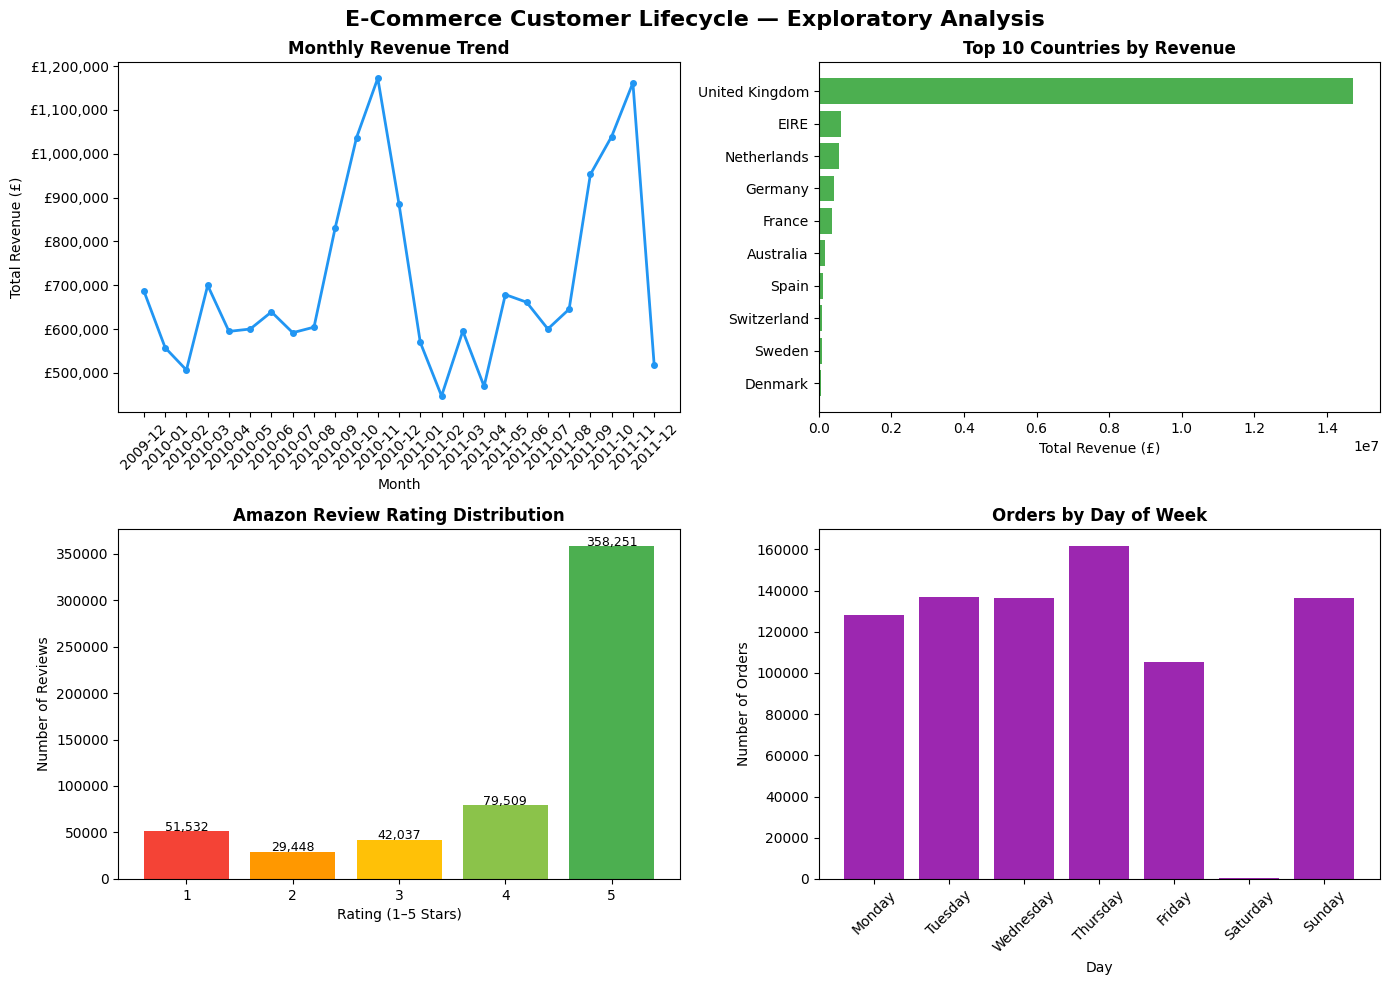

EDA charts generated and saved!


In [0]:
# ============================================================
# EDA — 4 key business charts
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'E-Commerce Customer Lifecycle — Exploratory Analysis',
    fontsize=16, fontweight='bold'
)

# Chart 1 — Monthly revenue trend
monthly = retail_clean.groupby(
    retail_clean['InvoiceDate'].dt.to_period('M')
)['TotalSpend'].sum().reset_index()
monthly['InvoiceDate'] = monthly['InvoiceDate'].astype(str)

axes[0,0].plot(
    monthly['InvoiceDate'],
    monthly['TotalSpend'],
    color='#2196F3', linewidth=2, marker='o', markersize=4
)
axes[0,0].set_title('Monthly Revenue Trend', fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Total Revenue (£)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{x:,.0f}')
)

# Chart 2 — Top 10 countries by revenue
top_countries = retail_clean.groupby('Country')['TotalSpend'] \
    .sum().sort_values(ascending=False).head(10)

axes[0,1].barh(
    top_countries.index[::-1],
    top_countries.values[::-1],
    color='#4CAF50'
)
axes[0,1].set_title('Top 10 Countries by Revenue', fontweight='bold')
axes[0,1].set_xlabel('Total Revenue (£)')

# Chart 3 — Amazon review rating distribution
rating_counts = reviews_clean['Rating'].value_counts().sort_index()
colors = ['#F44336','#FF9800','#FFC107','#8BC34A','#4CAF50']
axes[1,0].bar(rating_counts.index, rating_counts.values, color=colors)
axes[1,0].set_title('Amazon Review Rating Distribution', fontweight='bold')
axes[1,0].set_xlabel('Rating (1–5 Stars)')
axes[1,0].set_ylabel('Number of Reviews')
for idx, val in rating_counts.items():
    axes[1,0].text(idx, val + 500, f'{val:,}', ha='center', fontsize=9)

# Chart 4 — Orders by day of week
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
day_counts = retail_clean['Day'].value_counts().reindex(day_order)
axes[1,1].bar(day_counts.index, day_counts.values, color='#9C27B0')
axes[1,1].set_title('Orders by Day of Week', fontweight='bold')
axes[1,1].set_xlabel('Day')
axes[1,1].set_ylabel('Number of Orders')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/tmp/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA charts generated and saved!")

### Save Cleaned Data to S3

In [0]:
# ============================================================
# Save cleaned datasets to S3 processed/ folder
# ============================================================

print("Saving cleaned datasets to S3...\n")

# Save Online Retail cleaned
retail_buffer = io.BytesIO()
retail_clean.to_parquet(retail_buffer, index=False)
retail_buffer.seek(0)
s3.put_object(
    Bucket = BUCKET,
    Key    = "processed/retail_clean.parquet",
    Body   = retail_buffer.getvalue()
)
print("Saved : processed/retail_clean.parquet")

# Save Reviews cleaned
reviews_buffer = io.BytesIO()
reviews_clean.to_parquet(reviews_buffer, index=False)
reviews_buffer.seek(0)
s3.put_object(
    Bucket = BUCKET,
    Key    = "processed/reviews_clean.parquet",
    Body   = reviews_buffer.getvalue()
)
print("Saved : processed/reviews_clean.parquet")

# Verify files saved in S3
print("\n=== Files in S3 processed/ folder ===")
response = s3.list_objects_v2(Bucket=BUCKET, Prefix="processed/")
for obj in response.get("Contents", []):
    size_mb = round(obj["Size"] / 1024 / 1024, 2)
    print(f"  {obj['Key']:<45} {size_mb} MB")

print("\n" + "="*50)
print("DATA PREPARATION COMPLETE!")
print("="*50)
print("Next step : Module 1 — Recommendation System")
print("Notebook  : 02_recommendation/02_recommendation")

Saving cleaned datasets to S3...

Saved : processed/retail_clean.parquet
Saved : processed/reviews_clean.parquet

=== Files in S3 processed/ folder ===
  processed/                                    0.0 MB
  processed/retail_clean.parquet                6.29 MB
  processed/retail_clean.parquet/_SUCCESS       0.0 MB
  processed/retail_clean.parquet/_committed_4349841374952309096 0.0 MB
  processed/retail_clean.parquet/_committed_6307710306826115460 0.0 MB
  processed/retail_clean.parquet/_started_4349841374952309096 0.0 MB
  processed/retail_clean.parquet/_started_6307710306826115460 0.0 MB
  processed/retail_clean.parquet/part-00000-tid-6307710306826115460-242a371e-4339-4cd2-8a18-deace059317e-374-1.c000.snappy.parquet 0.78 MB
  processed/retail_clean.parquet/part-00001-tid-6307710306826115460-242a371e-4339-4cd2-8a18-deace059317e-375-1.c000.snappy.parquet 0.77 MB
  processed/retail_clean.parquet/part-00002-tid-6307710306826115460-242a371e-4339-4cd2-8a18-deace059317e-370-1.c000.snappy.p